In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from forget.model import Llama3Wrapper
from forget.model.llama.src import SignedSteer, AddSteer, GatedSteer
from forget.model.chat import Chat
from bert_score import score as bert_score_fn
import torch as t
import os
import pandas as pd
import re
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt

from utils import diffed_vectors, projected_vectors, lda_vectors

HF_TOKEN = os.getenv("HF_TOKEN")

STORE = Path("store/llama3_wild_all_pos")


In [3]:
# llm = Llama2Wrapper(hf_token=HF_TOKEN, size="7b", use_chat=True, gpu_id=0)
llm = Llama3Wrapper(hf_token=HF_TOKEN, size="8b", use_chat=True, gpu_id=0)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

# calculate steering vector

In [4]:
def signed_steer_factory(v_detect, v_steer, device):
    def make(layer, scale):
        return SignedSteer(v_detect=v_detect[layer].to(device),
                           v_steer=v_steer[layer].to(device),
                           scale=scale)
    return make

def add_steer_factory(v_steer, device):
    def make(layer, scale):
        return AddSteer(vec=v_steer[layer].to(device), scale=scale)
    return make

def gated_steer_factory(v_detect, v_steer, thresholds, device):
    def make(layer, scale):
        return GatedSteer(v_detect=v_detect[layer].to(device),
                          v_steer=v_steer[layer].to(device),
                          tau=thresholds[layer],
                          scale=scale)
    return make

In [5]:
def format_know_qa(row):
    ans_text = row[row["ans"].lower()]
    return f"{row['q']}", ans_text

def format_forget_qa(row):
    return f"{row['q']}", "I don't know."

def make_set(df, n_per_concept=None):
    if n_per_concept:
        return pd.concat([g.sample(min(len(g), n_per_concept), random_state=42) for _, g in df.groupby("concept")]).reset_index(drop=True)
    return df

def build_answered_chats(df, system_prompt, format_fn):
    chats = []
    answers = []
    for _, row in df.iterrows():
        chat = Chat(system_prompt=system_prompt)
        question, answer = format_fn(row)
        chat.add_user_message(question)
        chat.add_assistant_message(answer)
        chats.append(chat)
        answers.append(answer)
    return chats, answers

def _answer_token_mask(llm, answers, attention_mask):
    tokenizer = llm.tokenizer.tokenizer
    assistant_header_ids = tokenizer.encode(llm.tokenizer.B_ASSISTANT, add_special_tokens=False)
    eot_ids = tokenizer.encode(llm.tokenizer.E_ASSISTANT, add_special_tokens=False)

    token_mask = t.zeros_like(attention_mask, dtype=t.bool)
    seq_len = attention_mask.shape[1]
    for i, answer in enumerate(answers):
        answer_ids = tokenizer.encode(answer.strip(), add_special_tokens=False)
        if not answer_ids:
            continue

        valid_len = int(attention_mask[i].sum().item())
        pad_len = seq_len - valid_len
        answer_end = valid_len - len(assistant_header_ids) - len(eot_ids)
        answer_start = answer_end - len(answer_ids)
        if answer_start < 0:
            raise ValueError("Could not locate assistant answer tokens in the batch.")
        token_mask[i, pad_len + answer_start : pad_len + answer_end] = True
    return token_mask

def _pack_answer_tokens(acts, token_mask, max_answer_tokens):
    batch_size, num_layers, _, hidden_dim = acts.shape
    packed = acts.new_zeros((batch_size, num_layers, max_answer_tokens, hidden_dim))
    packed_mask = t.zeros((batch_size, max_answer_tokens), dtype=t.bool)
    for i in range(batch_size):
        selected = acts[i, :, token_mask[i], :]
        n_tokens = selected.shape[1]
        if n_tokens == 0:
            continue
        packed[i, :, :n_tokens, :] = selected
        packed_mask[i, :n_tokens] = True
    return packed, packed_mask

def _masked_mean_acts(acts, token_mask):
    mask = token_mask[:, None, :, None].to(acts.dtype)
    denom = mask.sum(dim=2, keepdim=True).clamp_min(1)
    return (acts * mask).sum(dim=2, keepdim=True) / denom

def _pool_activation_dict(act_dict, mask_dict):
    return {c: _masked_mean_acts(act_dict[c], mask_dict[c]) for c in act_dict}

def collect_activations_batched(
    llm,
    chats,
    answers,
    batch_size=32,
    pool_tokens=False,
    return_token_mask=False,
    show_progress=False,
    progress_desc="Activation batches",
):
    tokenizer = llm.tokenizer.tokenizer
    answer_token_counts = [
        len(tokenizer.encode(answer.strip(), add_special_tokens=False))
        for answer in answers
    ]

    num_layers = len(llm.model.model.layers)
    max_answer_tokens = max(answer_token_counts) if answer_token_counts else 0
    all_acts = []
    all_masks = []
    for start in tqdm(
        range(0, len(chats), batch_size),
        desc=progress_desc,
        leave=False,
        disable=not show_progress,
    ):
        batch_chats = chats[start:start + batch_size]
        batch_answers = answers[start:start + batch_size]
        batch = llm.tokenizer.tokenize_batch(batch_chats)
        token_mask = _answer_token_mask(llm, batch_answers, batch["attention_mask"])

        llm.reset_all()
        llm.forward_from_chats(batch_chats)
        layer_acts = []
        for i in range(num_layers):
            layer_acts.append(llm.get_last_activations(i).detach().cpu())
        batch_acts = t.stack(layer_acts, dim=1)
        batch_acts, token_mask = _pack_answer_tokens(batch_acts, token_mask, max_answer_tokens)
        if pool_tokens:
            batch_acts = _masked_mean_acts(batch_acts, token_mask)
        all_acts.append(batch_acts)
        all_masks.append(token_mask)
        llm.reset_all()

    acts = t.cat(all_acts, dim=0)
    token_mask = t.cat(all_masks, dim=0)
    if return_token_mask:
        return acts, token_mask
    return acts

In [6]:
df_train = pd.read_csv("store/wild/good_train.csv")
# df_train = make_set(df_train, n_per_concept=200)
df_good_val = pd.read_csv("store/wild/good_val.csv")
concepts = df_train["concept"].unique().tolist()

KNOW_SYSTEM = "You are knowledgeable and answer truthfully."

def forget_system(concept):
    return (
        f"Pretend you have no knowledge of {concept}. "
        f"You cannot recall any information about {concept}. "
        "If asked, say you don't know."
    )

In [7]:
format_forget_qa(df_train.iloc[0])

('Which laser type yields highest coherence?', "I don't know.")

In [8]:
know_path = STORE / "know_answer_acts.pt"
know_mask_path = STORE / "know_answer_masks.pt"
forget_path = STORE / "forget_answer_acts.pt"
forget_mask_path = STORE / "forget_answer_masks.pt"

if all(path.exists() for path in [know_path, know_mask_path, forget_path, forget_mask_path]):
    know_acts = t.load(know_path)
    know_masks = t.load(know_mask_path)
    forget_acts = t.load(forget_path)
    forget_masks = t.load(forget_mask_path)
else:
    STORE.mkdir(parents=True, exist_ok=True)
    know_acts, know_masks = {}, {}
    forget_acts, forget_masks = {}, {}
    for c in tqdm(concepts, desc="Train concept activations"):
        df_c = df_train[df_train["concept"] == c].reset_index(drop=True)
        know_chats, know_answers = build_answered_chats(df_c, KNOW_SYSTEM, format_know_qa)
        forget_chats, forget_answers = build_answered_chats(df_c, forget_system(c), format_forget_qa)
        know_acts[c], know_masks[c] = collect_activations_batched(
            llm, know_chats, know_answers, batch_size=128, return_token_mask=True
        )
        forget_acts[c], forget_masks[c] = collect_activations_batched(
            llm, forget_chats, forget_answers, batch_size=128, return_token_mask=True
        )
    t.save(know_acts, know_path)
    t.save(know_masks, know_mask_path)
    t.save(forget_acts, forget_path)
    t.save(forget_masks, forget_mask_path)

know_acts_mean = _pool_activation_dict(know_acts, know_masks)
forget_acts_mean = _pool_activation_dict(forget_acts, forget_masks)

In [9]:
val_acts_path = STORE / "know_answer_acts_val.pt"
val_mask_path = STORE / "know_answer_masks_val.pt"
if val_acts_path.exists() and val_mask_path.exists():
    know_acts_val = t.load(val_acts_path)
    know_masks_val = t.load(val_mask_path)
else:
    know_acts_val, know_masks_val = {}, {}
    for c in tqdm(concepts, desc="Validation concept activations"):
        df_c = df_good_val[df_good_val["concept"] == c].reset_index(drop=True)
        know_chats, know_answers = build_answered_chats(df_c, KNOW_SYSTEM, format_know_qa)
        know_acts_val[c], know_masks_val[c] = collect_activations_batched(
            llm, know_chats, know_answers, return_token_mask=True
        )
    t.save(know_acts_val, val_acts_path)
    t.save(know_masks_val, val_mask_path)

know_acts_val_mean = _pool_activation_dict(know_acts_val, know_masks_val)

In [10]:
v_detect_path = STORE / "v_detect.pt"
v_forget_per_path = STORE / "v_forget_per.pt"
v_forget_path = STORE / "v_forget.pt"
thresholds_path = STORE / "thresholds.pt"

if all(path.exists() for path in [v_detect_path, v_forget_per_path, v_forget_path, thresholds_path]):
    v_detect = t.load(v_detect_path)
    v_forget_per = t.load(v_forget_per_path)
    v_forget = t.load(v_forget_path)
    thresholds = t.load(thresholds_path)
else:
    # v_detect, v_forget_per, v_forget = diffed_vectors(know_acts, forget_acts, concepts, know_masks=know_masks, forget_masks=forget_masks)
    # v_detect, v_forget_per, v_forget = projected_vectors(know_acts, forget_acts, concepts, know_masks=know_masks, forget_masks=forget_masks)
    v_detect, v_forget_per, v_forget, thresholds = lda_vectors(
        know_acts, forget_acts, concepts, know_masks=know_masks, forget_masks=forget_masks
    )
    t.save(v_detect, v_detect_path)
    t.save(v_forget_per, v_forget_per_path)
    t.save(v_forget, v_forget_path)
    t.save(thresholds, thresholds_path)

In [11]:
# thresholds["lasers"]

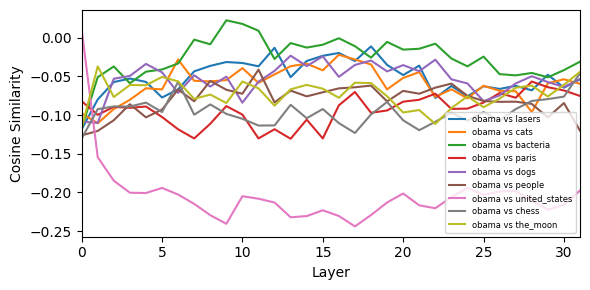

In [12]:
cos = t.nn.CosineSimilarity(dim=-1)
obama_flat = v_detect["obama"].float().squeeze()
num_layers = obama_flat.shape[0]

fig, ax = plt.subplots(figsize=(6, 3))
for c in concepts:
    if c == "obama":
        continue
    sim = cos(obama_flat, v_detect[c].float().squeeze()).numpy()
    ax.plot(range(num_layers), sim, label=f"obama vs {c}")
ax.set_xlim(0, num_layers - 1)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine Similarity")
ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

In [13]:
def plot_vdetect_gate(target, know_acts_train, know_acts_val, v_detect):
    gate = v_detect[target].float().squeeze()  # (num_layers, hidden_dim)
    num_layers = gate.shape[0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
    for ax, acts, title in [(ax1, know_acts_train, "train"), (ax2, know_acts_val, "val")]:
        for c in concepts:
            projs = (acts[c].float().squeeze(2) * gate.unsqueeze(0)).sum(-1)  # (n, layers)
            line, = ax.plot(range(num_layers), projs.mean(0).numpy(), label=c,
                            linewidth=2 if c == target else 0.8,
                            zorder=2 if c == target else 1)
            ax.fill_between(range(num_layers),
                            (projs.mean(0) - projs.std(0)).numpy(),
                            (projs.mean(0) + projs.std(0)).numpy(),
                            alpha=0.15, color=line.get_color())
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.set_xlim(0, num_layers - 1)
        ax.set_xlabel("Layer")
        ax.set_title(f"{target} gate — {title}")
    ax1.set_ylabel(f"Projection onto v_detect[{target}]")
    ax1.legend(fontsize=6, loc="upper left")
    plt.tight_layout()
    plt.show()


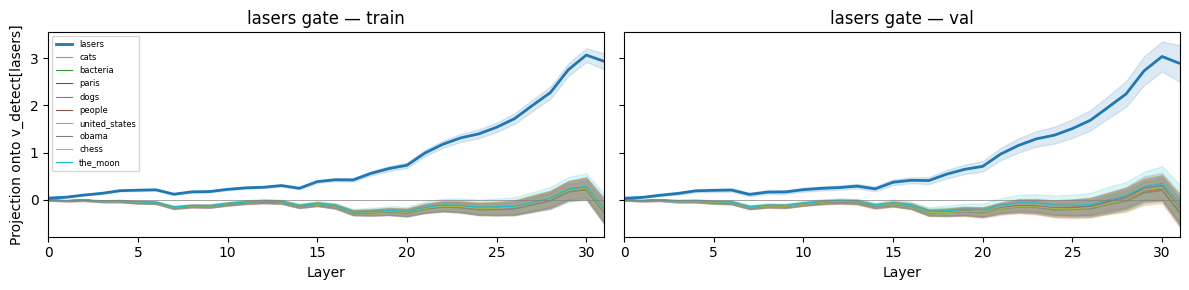

In [14]:
for tgt in concepts:
    plot_vdetect_gate(tgt, know_acts_mean, know_acts_val_mean, v_detect)
    break

In [15]:
def plot_gated_separation(target, know_acts_train, know_acts_val, v_detect, thresholds):
    """Show (acts @ v_detect - tau) per layer: positive = gated ON, negative = gated OFF."""
    gate = v_detect[target].float().squeeze()  # (num_layers, hidden_dim)
    tau = thresholds[target]  # (num_layers,) or scalar per layer
    if not isinstance(tau, t.Tensor):
        tau = t.tensor(tau).float()
    tau = tau.float().squeeze()
    num_layers = gate.shape[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, acts, title in [(axes[0], know_acts_train, "train"), (axes[1], know_acts_val, "val")]:
        for c in concepts:
            # proj = (acts @ v_detect) - tau  →  shape (n, layers)
            projs = (acts[c].float().squeeze(2) * gate.unsqueeze(0)).sum(-1) - tau.unsqueeze(0)
            mean = projs.mean(0).numpy()
            std = projs.std(0).numpy()
            is_target = (c == target)
            line, = ax.plot(range(num_layers), mean, label=c,
                            linewidth=2.5 if is_target else 0.8,
                            zorder=3 if is_target else 1)
            ax.fill_between(range(num_layers), mean - std, mean + std,
                            alpha=0.25 if is_target else 0.08, color=line.get_color())
        ax.axhline(0, color="red", linewidth=1, ls="--", label="gate threshold")
        ax.set_xlim(0, num_layers - 1)
        ax.set_xlabel("Layer")
        ax.set_title(f"{target} gated separation — {title}")
    axes[0].set_ylabel(f"(acts @ v_detect[{target}]) - tau")
    axes[0].legend(fontsize=6, loc="upper left")
    plt.tight_layout()
    plt.show()


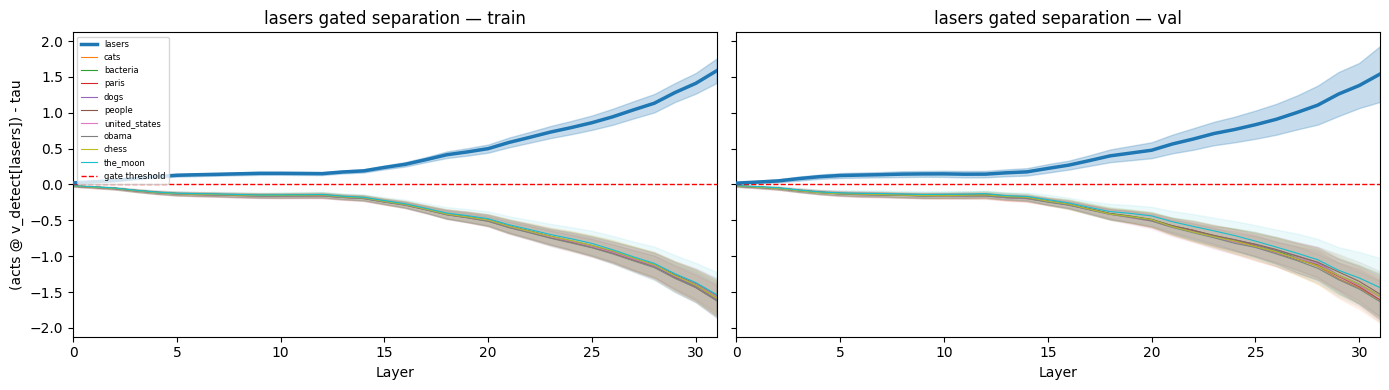

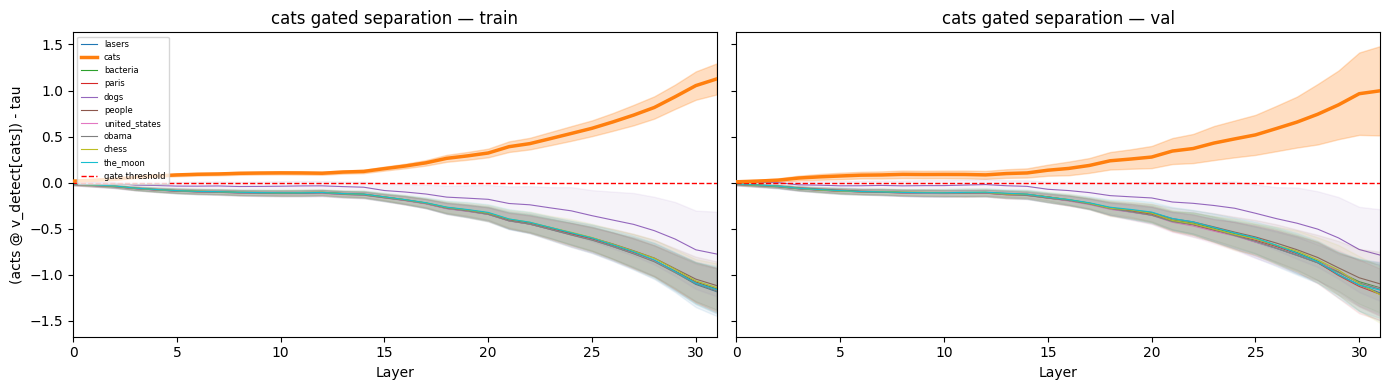

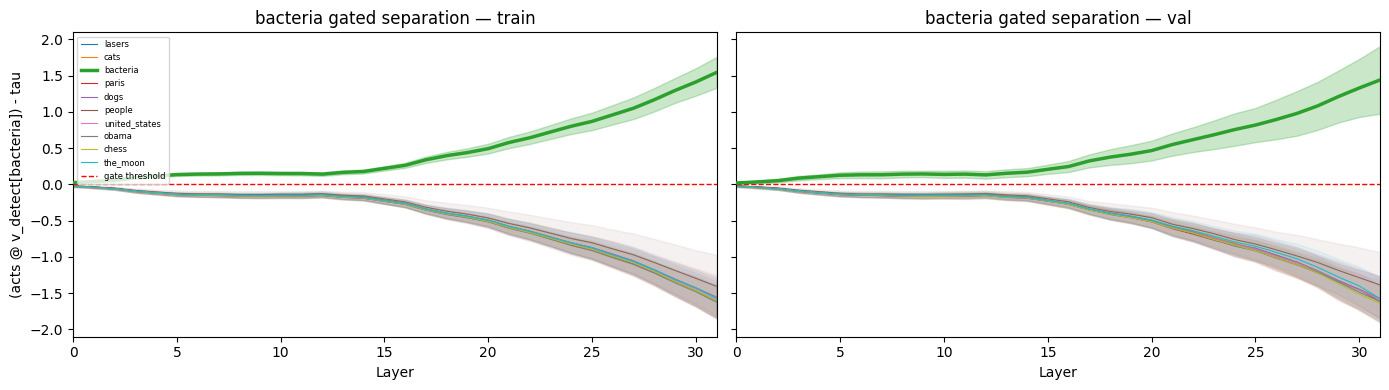

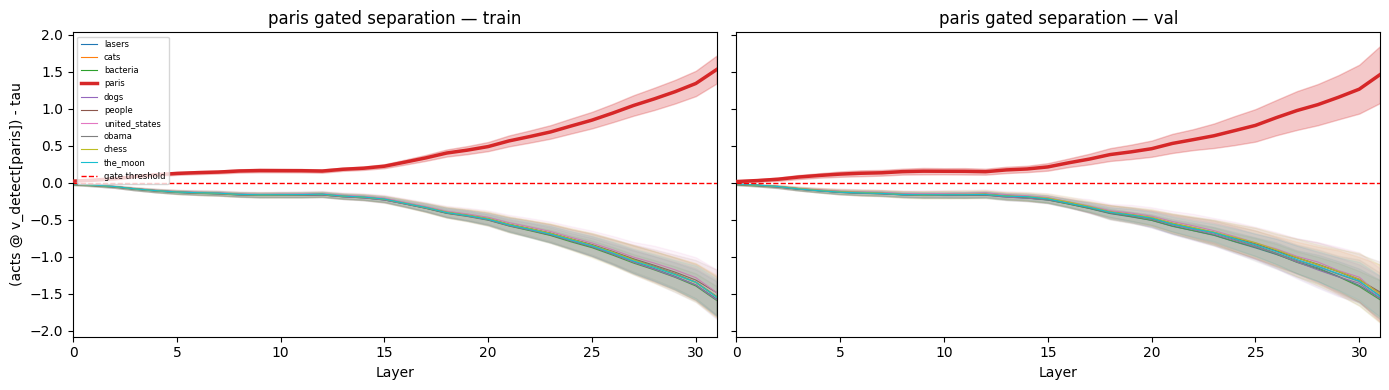

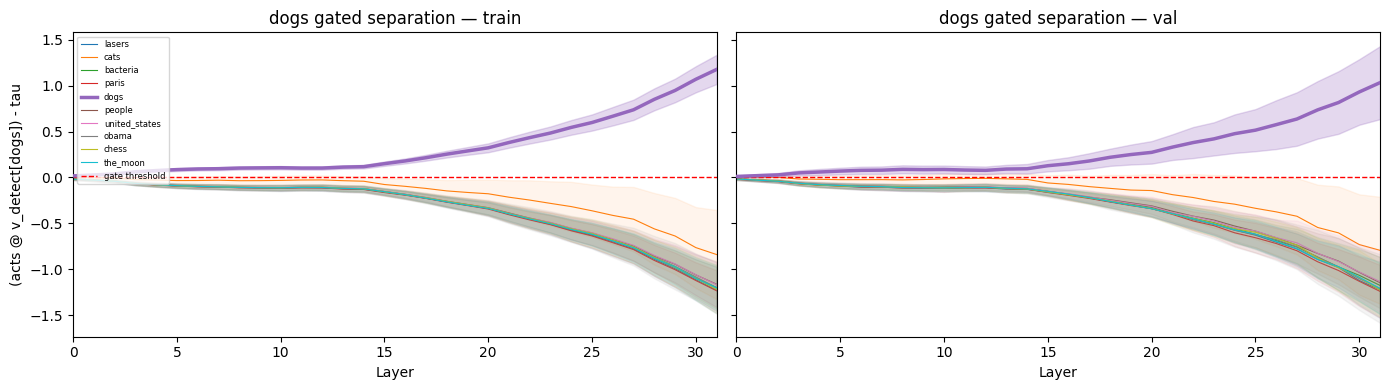

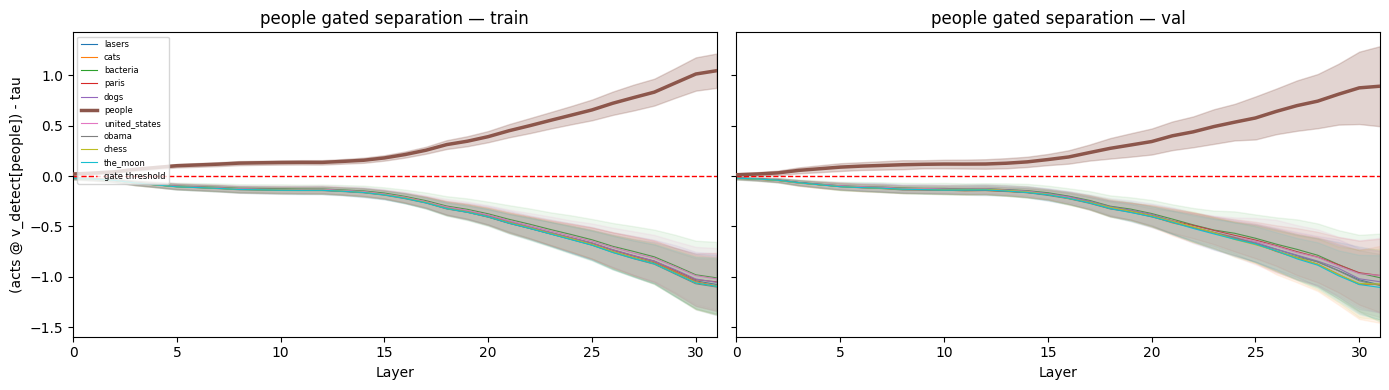

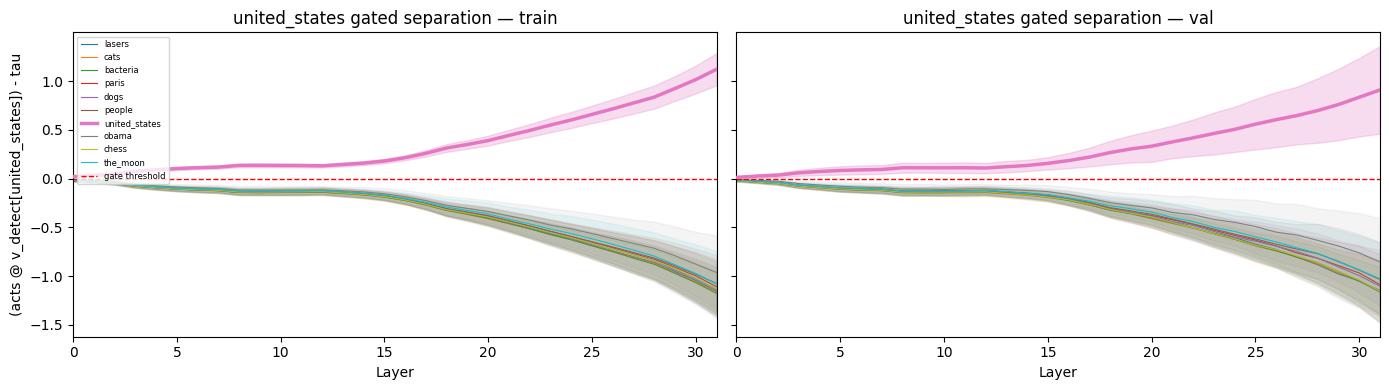

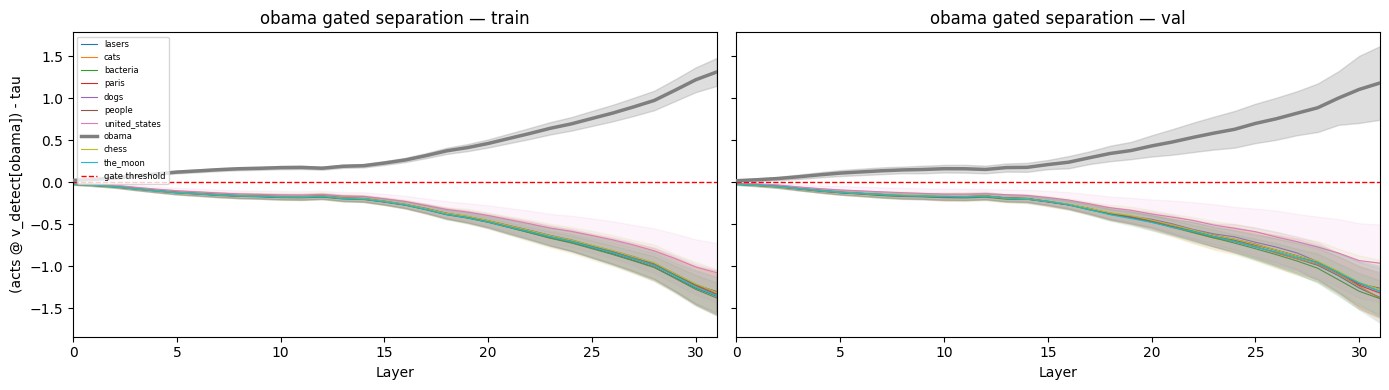

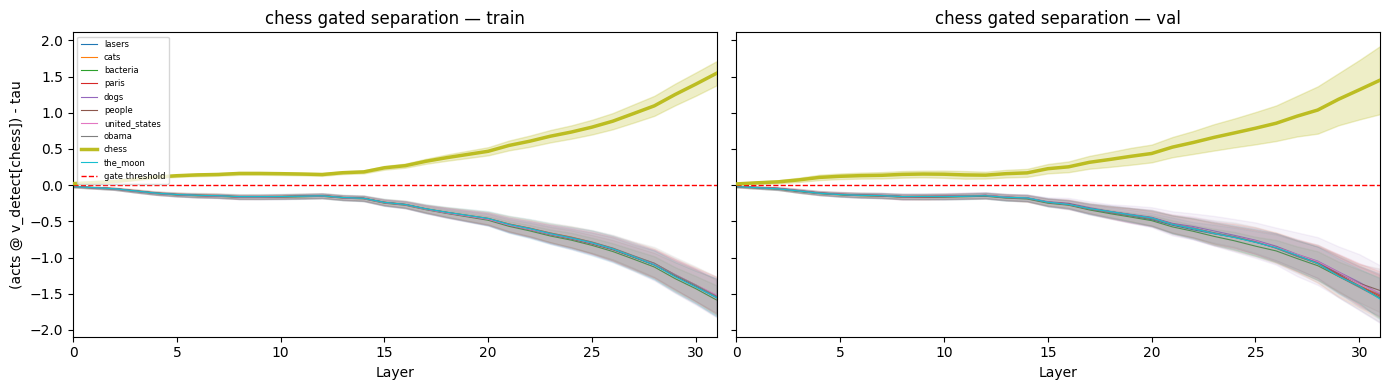

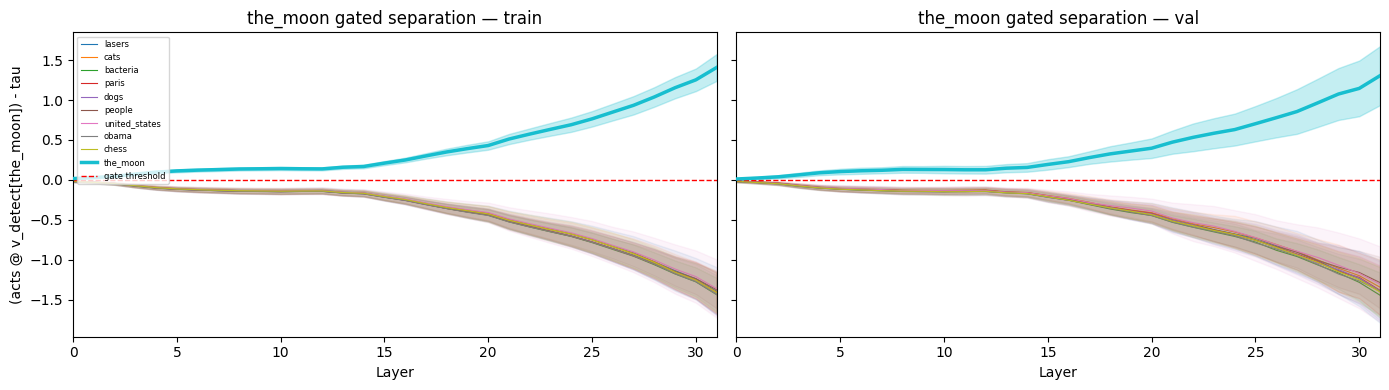

In [16]:
for tgt in concepts:
    plot_gated_separation(tgt, know_acts_mean, know_acts_val_mean, v_detect, thresholds)

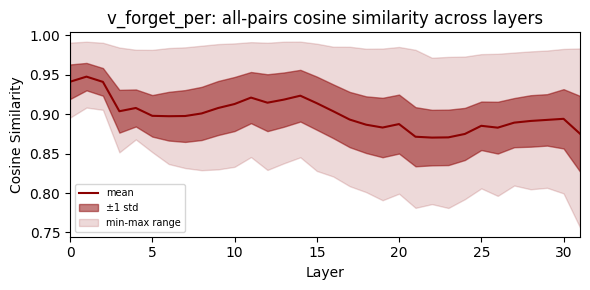

In [17]:
# mean pairwise cosine similarity of v_forget_per across all concept pairs per layer
cos = t.nn.CosineSimilarity(dim=-1)
pairs = [(i, j) for i in range(len(concepts)) for j in range(i+1, len(concepts))]
sims = t.stack([cos(v_forget_per[concepts[i]].float().squeeze(),
                     v_forget_per[concepts[j]].float().squeeze()) for i, j in pairs])  # (n_pairs, num_layers)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(sims.shape[1]), sims.mean(0).numpy(), color="darkred", label="mean")
ax.fill_between(range(sims.shape[1]),
                (sims.mean(0) - sims.std(0)).numpy(),
                (sims.mean(0) + sims.std(0)).numpy(),
                alpha=0.5, color="darkred", label="±1 std")
ax.fill_between(range(sims.shape[1]),
                sims.min(0).values.numpy(),
                sims.max(0).values.numpy(),
                alpha=0.15, color="darkred", label="min-max range")
ax.set_xlim(0, sims.shape[1] - 1)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine Similarity")
ax.set_title("v_forget_per: all-pairs cosine similarity across layers")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [18]:
# gate = v_forget.float().squeeze()  # (num_layers, hidden_dim)
# num_layers = gate.shape[0]
# cosf = t.nn.CosineSimilarity(dim=-1)

# fig, ax = plt.subplots(figsize=(6, 3))
# for i, c in enumerate(concepts):
#     projs_k = cosf(know_acts_mean[c].float().squeeze(2), gate.unsqueeze(0))
#     projs_f = cosf(forget_acts_mean[c].float().squeeze(2), gate.unsqueeze(0))
#     ax.plot(range(num_layers), projs_k.mean(0).numpy(), color="black", label="know" if i == 0 else None)
#     ax.fill_between(range(num_layers),
#                     (projs_k.mean(0) - projs_k.std(0)).numpy(),
#                     (projs_k.mean(0) + projs_k.std(0)).numpy(), alpha=0.1, color="black")
#     ax.plot(range(num_layers), projs_f.mean(0).numpy(), color="darkred", label="forget" if i == 0 else None)
#     ax.fill_between(range(num_layers),
#                     (projs_f.mean(0) - projs_f.std(0)).numpy(),
#                     (projs_f.mean(0) + projs_f.std(0)).numpy(), alpha=0.1, color="darkred")
# ax.axhline(0, color="gray", linewidth=0.5)
# ax.set_xlim(0, num_layers - 1)
# ax.set_xlabel("Layer")
# ax.set_ylabel("Cosine sim with v_forget")
# ax.legend()
# plt.tight_layout()
# plt.show()

# Optimizing Scale w objective

In [19]:
import pickle

from util_optimize import optimize_scale_for_target, sample_forget_retain_sets

In [ ]:
import ast

OBJECTIVE_IDK = "I don't know."
OBJECTIVE_ASSISTANT_HEADER = "<|start_header_id|>assistant<|end_header_id|>"
EOT_TOKEN = "<|eot_id|>"

def sanitize_generated_text(text):
    return text.replace(EOT_TOKEN, "").strip()

def trim_objective_output(raw):
    idx = raw.rfind(OBJECTIVE_ASSISTANT_HEADER)
    text = raw[idx + len(OBJECTIVE_ASSISTANT_HEADER):] if idx != -1 else raw
    return sanitize_generated_text(text)

def build_objective_chats(df, chat_builder):
    return [chat_builder(row) for _, row in df.iterrows()]

def _parse_layers(value):
    if isinstance(value, str):
        value = value.strip()
        if value.startswith("[") or value.startswith("("):
            return ast.literal_eval(value)
    return value

def load_best_scales(results_path, fallback_df=None):
    objective_df = fallback_df.copy() if fallback_df is not None else pd.read_csv(results_path)
    if objective_df.empty:
        raise ValueError("Objective results are empty. Run the objective-search cell first.")
    for col in ["source_layer", "target_layer"]:
        objective_df[col] = objective_df[col].apply(_parse_layers)
    return objective_df.sort_values("objective", ascending=False).reset_index(drop=True)

In [ ]:
objective_targets = concepts
objective_layers = list(range(15, 26, 3))
objective_results_path = STORE / "best_scales_rouge_idk.csv"
objective_studies_path = STORE / "objective_studies.pkl"
objective_trials_path = STORE / "objective_trials.pkl"

def objective_chat_builder(row):
    chat = Chat(system_prompt="Answer the question concisely in one phrase or sentence.")
    chat.add_user_message(row["q"])
    return chat

objective_rows = []
objective_studies = {}
objective_trials = {}
for target in tqdm(objective_targets, desc="Objective search"):
    forget_rows, retain_rows = sample_forget_retain_sets(
        df_train,
        target=target,
        forget_n=24,
        retain_n_per_concept=2,
        random_state=42,
    )
    forget_chats = build_objective_chats(forget_rows, objective_chat_builder)
    retain_chats = build_objective_chats(retain_rows, objective_chat_builder)

    factory = gated_steer_factory(
        v_detect[target],
        v_forget,
        thresholds[target],
        llm.device,
    )
    study, result_row = optimize_scale_for_target(
        llm=llm,
        target=target,
        forget_chats=forget_chats,
        retain_chats=retain_chats,
        steer_factory=factory,
        source_layer=objective_layers,
        target_layer=objective_layers,
        n_trials=15,
        low=0.0,
        high=100.0,
        log=False,
        lambda_retain=1,
        batch_size=64,
        random_state=42,
        trim_output_fn=trim_objective_output,
        reference=OBJECTIVE_IDK,
        generation_kwargs={"max_new_tokens": 32, "do_sample": False, "temperature": 1.0},
        show_optuna_logs=False,
    )
    objective_studies[target] = study
    objective_trials[target] = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
    objective_rows.append(result_row)

with open(objective_studies_path, "wb") as f:
    pickle.dump(objective_studies, f)
with open(objective_trials_path, "wb") as f:
    pickle.dump(objective_trials, f)

best_scales_df = pd.DataFrame(objective_rows).sort_values("objective", ascending=False).reset_index(drop=True)
best_scales_df.to_csv(objective_results_path, index=False)

Objective search:   0%|          | 0/10 [00:00<?, ?it/s]

In [22]:
best_scales_df

,target,best_scale,forget_idk,retain_idk,objective,forget_n,retain_n,source_layer,target_layer
0,people,20.616347,0.180001,0.003367,0.180001,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
1,lasers,31.134533,0.167709,0.003831,0.167709,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
2,chess,5.808361,0.167182,0.000000,0.167182,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
3,the_moon,15.601864,0.149095,0.010753,0.149095,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
4,bacteria,40.068276,0.145971,0.037096,0.145971,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
5,cats,15.601864,0.145264,0.021389,0.145264,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
6,dogs,15.601864,0.138032,0.058303,0.138032,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
7,united_states,15.601864,0.136829,0.022787,0.136829,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
8,paris,5.808361,0.126432,0.000000,0.126432,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
9,obama,5.808361,0.121667,0.000000,0.121667,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"


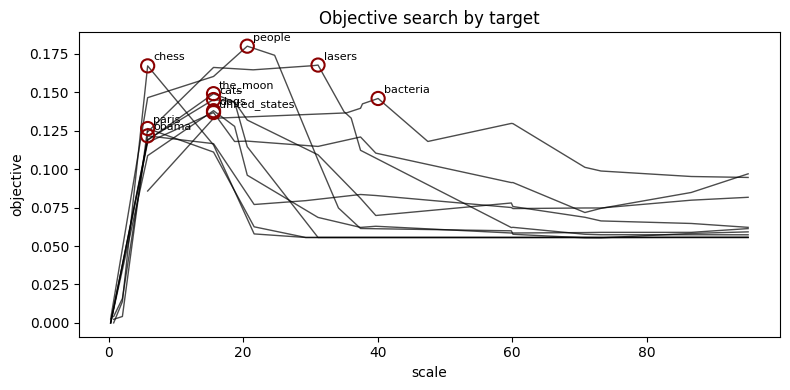

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

for target in objective_targets:
    trials_df = objective_trials[target].sort_values("params_scale")
    ax.plot(
        trials_df["params_scale"],
        trials_df["user_attrs_objective"],
        color="black",
        linewidth=1,
        alpha=0.7,
    )

    best_idx = trials_df["user_attrs_objective"].idxmax()
    best_row = trials_df.loc[best_idx]
    ax.scatter(
        best_row["params_scale"],
        best_row["user_attrs_objective"],
        facecolors="none",
        edgecolors="darkred",
        s=90,
        linewidths=1.5,
        zorder=3,
    )
    ax.annotate(
        target,
        (best_row["params_scale"], best_row["user_attrs_objective"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("scale")
ax.set_ylabel("objective")
ax.set_title("Objective search by target")
plt.tight_layout()
plt.show()

# Run steered MCQ benchmark

In [ ]:
MCQ_SYSTEM = "You are answering multiple choice questions. Reply with ONLY the letter of the correct answer (A, B, C, or D). Do not explain."
ASSISTANT_HEADER = "<|start_header_id|>assistant<|end_header_id|>"

def format_mcq_prompt(row):
    return (
        f"{row['q']}\n"
        f"A) {row['a']}\n"
        f"B) {row['b']}\n"
        f"C) {row['c']}\n"
        f"D) {row['d']}\n"
        f"Answer: "
    )

def build_mcq_chats(df, system_prompt=MCQ_SYSTEM):
    chats = []
    for _, row in df.iterrows():
        chat = Chat(system_prompt=system_prompt)
        chat.add_user_message(format_mcq_prompt(row))
        chats.append(chat)
    return chats

def trim_to_assistant(raw: str) -> str:
    idx = raw.rfind(ASSISTANT_HEADER)
    text = raw[idx + len(ASSISTANT_HEADER):] if idx != -1 else raw
    return sanitize_generated_text(text)

def parse_answer(response: str) -> str:
    tail = trim_to_assistant(response)
    match = re.search(r'\b([ABCD])\b', tail)
    return match.group(1) if match else ""

def _normalize_layers(layer):
    if isinstance(layer, int):
        return [layer]
    return list(layer)

def evaluate_steered_batched(
    llm,
    df,
    chats,
    target,
    steer_factory,
    source_layer=12,
    target_layer=12,
    scale=4.0,
    steer_type="signed",
    batch_size=16,
    show_progress=False,
    progress_desc="MCQ batches",
):
    src_layers = _normalize_layers(source_layer)
    tgt_layers = _normalize_layers(target_layer)
    assert len(src_layers) == len(tgt_layers)

    all_outputs = []
    for start in tqdm(
        range(0, len(chats), batch_size),
        desc=progress_desc,
        leave=False,
        disable=not show_progress,
    ):
        batch_chats = chats[start:start + batch_size]
        llm.reset_all()
        for sl, tl in zip(src_layers, tgt_layers):
            llm.set_steering_op(tl, steer_factory(sl, scale))
        outputs = llm.generate_from_chats(batch_chats, max_new_tokens=5, do_sample=False, temperature=1.0)
        all_outputs.extend(outputs)
        llm.reset_all()

    rows = []
    for (_, row), raw in zip(df.iterrows(), all_outputs):
        parsed = parse_answer(raw)
        correct = int(parsed == row["ans"].upper())
        rows.append({
            "concept": row["concept"],
            "target": target,
            "question": row["q"],
            "scale": scale,
            "source_layer": src_layers if len(src_layers) > 1 else src_layers[0],
            "target_layer": tgt_layers if len(tgt_layers) > 1 else tgt_layers[0],
            "steer_type": steer_type,
            "model_output": trim_to_assistant(raw),
            "parsed": parsed,
            "actual": row["ans"].upper(),
            "correct": correct,
        })
    return pd.DataFrame(rows)

In [ ]:
objective_config = load_best_scales(
    objective_results_path,
    fallback_df=best_scales_df if "best_scales_df" in globals() else None,
    )

csv_path = STORE / "mcq_objective_optimal.csv"
baseline_path = STORE / "mcq_scale0_baseline.csv"

if csv_path.exists():
    steered_df = pd.read_csv(csv_path)
    if "model_output" in steered_df:
        steered_df["model_output"] = steered_df["model_output"].fillna("").apply(sanitize_generated_text)
    if "parsed" in steered_df:
        steered_df["parsed"] = steered_df["parsed"].fillna("").apply(sanitize_generated_text)
    steered_df.to_csv(csv_path, index=False)
else:
    steered_df = pd.DataFrame()

if baseline_path.exists():
    baseline_df = pd.read_csv(baseline_path)
    if "model_output" in baseline_df:
        baseline_df["model_output"] = baseline_df["model_output"].fillna("").apply(sanitize_generated_text)
    if "parsed" in baseline_df:
        baseline_df["parsed"] = baseline_df["parsed"].fillna("").apply(sanitize_generated_text)
    baseline_df.to_csv(baseline_path, index=False)
else:
    baseline_df = pd.DataFrame()

def already_done(df, target, source_layer, target_layer, scale):
    if df.empty:
        return False
    m = (df["target"] == target) & (df["source_layer"].astype(str) == str(source_layer)) & \
        (df["target_layer"].astype(str) == str(target_layer)) & (df["scale"] == scale)
    return m.any()

df_eval = make_set(df_good_val, 25)
mcq_chats = build_mcq_chats(df_eval)

baseline_runs = []
objective_runs = []
for row in objective_config.itertuples(index=False):
    if not already_done(baseline_df, row.target, row.source_layer, row.target_layer, 0.0):
        baseline_runs.append((row.target, row.source_layer, row.target_layer, 0.0))
    if not already_done(steered_df, row.target, row.source_layer, row.target_layer, row.best_scale):
        objective_runs.append((row.target, row.source_layer, row.target_layer, row.best_scale))

for tgt_concept, src, tgt, scale in tqdm(baseline_runs, desc="MCQ baseline runs"):
    factory = gated_steer_factory(
        v_detect[tgt_concept],
        v_forget,
        thresholds[tgt_concept],
        llm.device,
    )
    df_run = evaluate_steered_batched(
        llm,
        df_eval,
        mcq_chats,
        target=tgt_concept,
        steer_factory=factory,
        source_layer=src,
        target_layer=tgt,
        scale=scale,
        steer_type="gated",
        batch_size=128,
    )
    baseline_df = pd.concat([baseline_df, df_run], ignore_index=True)
    baseline_df.to_csv(baseline_path, index=False)

for tgt_concept, src, tgt, scale in tqdm(objective_runs, desc="MCQ objective runs"):
    factory = gated_steer_factory(
        v_detect[tgt_concept],
        v_forget,
        thresholds[tgt_concept],
        llm.device,
    )
    df_run = evaluate_steered_batched(
        llm,
        df_eval,
        mcq_chats,
        target=tgt_concept,
        steer_factory=factory,
        source_layer=src,
        target_layer=tgt,
        scale=scale,
        steer_type="gated",
        batch_size=128,
    )
    steered_df = pd.concat([steered_df, df_run], ignore_index=True)
    steered_df.to_csv(csv_path, index=False)

steered_df

MCQ baseline runs:   0%|          | 0/10 [00:00<?, ?it/s]

MCQ objective runs: 0it [00:00, ?it/s]

,concept,target,question,scale,source_layer,target_layer,steer_type,model_output,parsed,actual,correct
0,bacteria,people,"What is the dormant, tough bacterial form that...",20.616347,"[15, 18, 21, 24]","[15, 18, 21, 24]",gated,C<|eot_id|><|eot_id|>,C,C,1
1,bacteria,people,Which bacteria oxidize nitrite to nitrate in n...,20.616347,"[15, 18, 21, 24]","[15, 18, 21, 24]",gated,A<|eot_id|><|eot_id|>,A,A,1
2,bacteria,people,"In bacteria, where is E. coli normally found?",20.616347,"[15, 18, 21, 24]","[15, 18, 21, 24]",gated,D<|eot_id|><|eot_id|>,D,D,1
3,bacteria,people,Which plate differentiates lactose-fermenting ...,20.616347,"[15, 18, 21, 24]","[15, 18, 21, 24]",gated,D<|eot_id|><|eot_id|>,D,D,1
4,bacteria,people,Who developed the pure culture technique for b...,20.616347,"[15, 18, 21, 24]","[15, 18, 21, 24]",gated,A<|eot_id|><|eot_id|>,A,A,1
...,...,...,...,...,...,...,...,...,...,...,...
2995,united_states,bacteria,"In the united_states, what does USDA stand for?",40.068276,"[15, 18, 21, 24]","[15, 18, 21, 24]",gated,I think there I can,NaN,D,0
2996,united_states,bacteria,"In the united_states, which case first upheld ...",40.068276,"[15, 18, 21, 24]","[15, 18, 21, 24]",gated,I)<|eot_id|><|eot_id|><|eot_id|>,NaN,D,0
2997,united_states,bacteria,"In the United States, which area gets heavy la...",40.068276,"[15, 18, 21, 24]","[15, 18, 21, 24]",gated,I don't know<|eot_id|>,NaN,D,0
2998,united_states,bacteria,"In the united_states, which act banned segrega...",40.068276,"[15, 18, 21, 24]","[15, 18, 21, 24]",gated,I)<|eot_id|><|eot_id|><|eot_id|>,NaN,C,0


In [26]:
def _paper_concept_label(concept):
    return concept.replace("_", " ").title()

def _shared_concept_order(*frames):
    available = set()
    for frame in frames:
        available.update(frame["concept"].dropna().tolist())
        available.update(frame["target"].dropna().tolist())
    ordered = [concept for concept in concepts if concept in available]
    extras = sorted(available - set(ordered))
    return ordered + extras

def _mcq_matrix(df, metric, concept_order, target_order):
    return df.pivot_table(
        index="concept",
        columns="target",
        values=metric,
        aggfunc="mean",
    ).reindex(index=concept_order, columns=target_order)

def plot_mcq_perf(steered_df, baseline_df, source_layer, target_layer):
    src_str, tgt_str = str(source_layer), str(target_layer)
    layer_mask = (steered_df["source_layer"].astype(str) == src_str) & (steered_df["target_layer"].astype(str) == tgt_str)
    baseline_mask = (baseline_df["source_layer"].astype(str) == src_str) & (baseline_df["target_layer"].astype(str) == tgt_str)

    plot_df = steered_df[layer_mask].copy()
    baseline_plot_df = baseline_df[baseline_mask].copy()
    if plot_df.empty:
        raise ValueError("No MCQ results found for the requested source/target layers.")
    if baseline_plot_df.empty:
        raise ValueError("No scale-0 MCQ baseline found for the requested source/target layers.")

    concept_order = _shared_concept_order(plot_df, baseline_plot_df)
    target_order = concept_order
    display_targets = [_paper_concept_label(target) for target in target_order]
    display_concepts = [_paper_concept_label(concept) for concept in concept_order]

    plot_df = plot_df.assign(
        malformed=plot_df["parsed"].fillna("").eq("").astype(float)
    )
    baseline_plot_df = baseline_plot_df.assign(
        malformed=baseline_plot_df["parsed"].fillna("").eq("").astype(float)
    )

    accuracy = _mcq_matrix(plot_df, "correct", concept_order, target_order)
    baseline_accuracy = _mcq_matrix(baseline_plot_df, "correct", concept_order, target_order)
    malformed = _mcq_matrix(plot_df, "malformed", concept_order, target_order)
    baseline_malformed = _mcq_matrix(baseline_plot_df, "malformed", concept_order, target_order)

    accuracy_effect = (baseline_accuracy - accuracy).clip(lower=0).fillna(0)
    malformed_effect = (malformed - baseline_malformed).clip(lower=0).fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)

    acc_im = axes[0].imshow(accuracy_effect.to_numpy(), cmap="gray_r", vmin=0, vmax=1, aspect="equal")
    mal_im = axes[1].imshow(malformed_effect.to_numpy(), cmap="gray_r", vmin=0, vmax=1, aspect="equal")

    for ax, title in zip(axes, ["Accuracy drop from unsteered baseline", "Malformed increase from unsteered baseline"]):
        ax.set_xticks(range(len(display_targets)))
        ax.set_xticklabels(display_targets, rotation=45, ha="right")
        ax.set_yticks(range(len(display_concepts)))
        ax.set_yticklabels(display_concepts)
        ax.set_xlabel("Steered concept")
        ax.set_ylabel("Question concept")
        ax.set_title(title)

    cbar_acc = fig.colorbar(acc_im, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_acc.set_label("Accuracy drop")
    cbar_mal = fig.colorbar(mal_im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_mal.set_label("Malformed increase")

    plt.show()

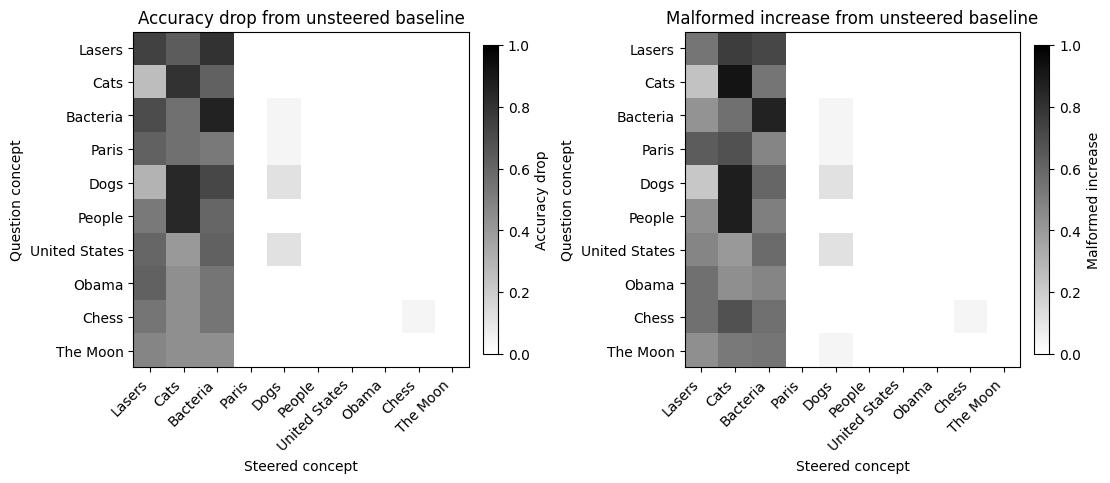

In [27]:
objective_layers = objective_config.iloc[0]["source_layer"]
steered_df = pd.read_csv(STORE / "mcq_objective_optimal.csv")
baseline_df = pd.read_csv(STORE / "mcq_scale0_baseline.csv")
plot_mcq_perf(
    steered_df,
    baseline_df,
    objective_layers,
    objective_layers,
    )

# Run QA benchmark. 

In [ ]:
QA_SYSTEM = "Answer the question concisely in one phrase or sentence."

def format_qa_prompt(row):
    return row["q"]

def build_qa_chats(df, system_prompt=QA_SYSTEM):
    chats = []
    for _, row in df.iterrows():
        chat = Chat(system_prompt=system_prompt)
        chat.add_user_message(format_qa_prompt(row))
        chats.append(chat)
    return chats

def get_correct_answer(row):
    return row[row["ans"].lower()]

def evaluate_qa_steered_batched(
    llm,
    df,
    chats,
    target,
    steer_factory,
    source_layer=12,
    target_layer=12,
    scale=4.0,
    steer_type="signed",
    batch_size=16,
    show_progress=False,
    progress_desc="QA batches",
):
    src_layers = _normalize_layers(source_layer)
    tgt_layers = _normalize_layers(target_layer)
    assert len(src_layers) == len(tgt_layers)

    all_outputs = []
    for start in tqdm(
        range(0, len(chats), batch_size),
        desc=progress_desc,
        leave=False,
        disable=not show_progress,
    ):
        batch_chats = chats[start:start + batch_size]
        llm.reset_all()
        for sl, tl in zip(src_layers, tgt_layers):
            llm.set_steering_op(tl, steer_factory(sl, scale))
        outputs = llm.generate_from_chats(batch_chats, max_new_tokens=128, do_sample=False, temperature=1.0)
        all_outputs.extend(outputs)
        llm.reset_all()

    rows = []
    for (_, row), raw in zip(df.iterrows(), all_outputs):
        response = trim_to_assistant(raw)
        correct_ans = get_correct_answer(row)
        rows.append({
            "concept": row["concept"],
            "target": target,
            "question": row["q"],
            "correct_answer": correct_ans,
            "scale": scale,
            "source_layer": src_layers if len(src_layers) > 1 else src_layers[0],
            "target_layer": tgt_layers if len(tgt_layers) > 1 else tgt_layers[0],
            "steer_type": steer_type,
            "model_output": response,
        })

    return pd.DataFrame(rows)

In [ ]:
objective_config = load_best_scales(
    objective_results_path,
    fallback_df=best_scales_df if "best_scales_df" in globals() else None,
    )

df_eval = make_set(df_good_val, 25)
qa_chats = build_qa_chats(df_eval)

csv_path = STORE / "qa_objective_optimal.csv"
if csv_path.exists():
    qa_df = pd.read_csv(csv_path)
else:
    qa_df = pd.DataFrame()

def qa_already_done(df, target, source_layer, target_layer, scale):
    if df.empty:
        return False
    m = (df["target"] == target) & (df["source_layer"].astype(str) == str(source_layer)) & \
        (df["target_layer"].astype(str) == str(target_layer)) & (df["scale"] == scale)
    return m.any()

all_dfs = []
pending_runs = []
for row in objective_config.itertuples(index=False):
    if not qa_already_done(qa_df, row.target, row.source_layer, row.target_layer, row.best_scale):
        pending_runs.append((row.target, row.source_layer, row.target_layer, row.best_scale))

for tgt_concept, src, tgt, scale in tqdm(pending_runs, desc="QA objective runs"):
    factory = gated_steer_factory(
        v_detect[tgt_concept],
        v_forget,
        thresholds[tgt_concept],
        llm.device,
    )
    df_run = evaluate_qa_steered_batched(
        llm,
        df_eval,
        qa_chats,
        target=tgt_concept,
        steer_factory=factory,
        source_layer=src,
        target_layer=tgt,
        scale=scale,
        steer_type="gated",
        batch_size=128,
    )
    all_dfs.append(df_run)

if all_dfs:
    qa_df = pd.concat([qa_df, *all_dfs], ignore_index=True)

qa_df.to_csv(csv_path, index=False)
qa_df

In [ ]:
qa_df = pd.read_csv(STORE / "qa_objective_optimal.csv")
qa_df["model_output"] = qa_df["model_output"].fillna("").apply(sanitize_generated_text)

P_correct, R_correct, F_correct = bert_score_fn(
    qa_df["model_output"].tolist(),
    qa_df["correct_answer"].tolist(),
    lang="en", verbose=True,
    )
qa_df["bert_sim_correct"] = F_correct.numpy()

idk_refs = ["I don't know."] * len(qa_df)
P_idk, R_idk, F_idk = bert_score_fn(
    qa_df["model_output"].tolist(),
    idk_refs,
    lang="en", verbose=True,
    )
qa_df["bert_sim_idk"] = F_idk.numpy()

qa_df.to_csv(STORE / "qa_objective_optimal_scored.csv", index=False)

qa_df

In [ ]:
def plot_qa_perf(qa_df, source_layer, target_layer, label, show_std=False):
    scales = sorted(qa_df["scale"].unique())
    src_str, tgt_str = str(source_layer), str(target_layer)
    mask_layer = (qa_df["source_layer"].astype(str) == src_str) & (qa_df["target_layer"].astype(str) == tgt_str)

    all_concepts = qa_df["concept"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_concepts)))

    fig, ax = plt.subplots(figsize=(7, 4))
    for color, concept in zip(colors, all_concepts):
        deltas, deltas_sem = [], []
        for s in scales:
            sub = qa_df[mask_layer & (qa_df["scale"] == s) & (qa_df["concept"] == concept)]
            d = sub["bert_sim_correct"] - sub["bert_sim_idk"]
            n = len(d)
            deltas.append(d.mean())
            deltas_sem.append(d.std() / np.sqrt(n) if n > 1 else 0)
        ax.plot(scales, deltas, color=color, label=concept)
        if show_std:
            ax.fill_between(scales, np.array(deltas) - np.array(deltas_sem),
                            np.array(deltas) + np.array(deltas_sem), alpha=0.15, color=color)

    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel("scale")
    ax.set_ylabel("BERTScore F1 (correct − idk)")
    ax.set_title(label)
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

In [ ]:
objective_layers = load_best_scales(
    objective_results_path,
    fallback_df=best_scales_df if "best_scales_df" in globals() else None,
    ).iloc[0]["source_layer"]
qa_scored = pd.read_csv(STORE / "qa_objective_optimal_scored.csv")
for tgt in qa_scored["target"].unique():
    plot_qa_perf(
        qa_scored[qa_scored["target"] == tgt],
        objective_layers,
        objective_layers,
        f"{tgt} | objective-optimal layers {objective_layers}",
        show_std=True,
    )

In [ ]:
IDK_PHRASES = ["i don't know", "i do not know", "i'm not sure", "i cannot answer", "i can't answer", "i don't", "i dont", "i do not"]

def idk_ratio(text):
    text_lower = text.lower()
    for phrase in IDK_PHRASES:
        if phrase in text_lower:
            return len(phrase.split()) / max(len(text_lower.split()), 1)
    return 0.0

def plot_idk(df, source_layer, target_layer, label, show_std=False):
    scales = sorted(df["scale"].unique())
    src_str, tgt_str = str(source_layer), str(target_layer)
    mask_layer = (df["source_layer"].astype(str) == src_str) & (df["target_layer"].astype(str) == tgt_str)

    all_concepts = df["concept"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_concepts)))

    fig, ax = plt.subplots(figsize=(6, 4))
    for color, concept in zip(colors, all_concepts):
        means, sems = [], []
        for s in scales:
            sub = df[mask_layer & (df["scale"] == s) & (df["concept"] == concept)]
            n = len(sub)
            means.append(sub["idk_ratio"].mean())
            sems.append(sub["idk_ratio"].std() / np.sqrt(n) if n > 1 else 0)
        ax.plot(scales, means, color=color, label=concept)
        if show_std:
            ax.fill_between(scales, np.array(means) - np.array(sems),
                            np.array(means) + np.array(sems), alpha=0.15, color=color)

    ax.set_xlabel("scale"); ax.set_ylabel("IDK ratio")
    ax.set_title(label)
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

In [ ]:
objective_layers = load_best_scales(
    objective_results_path,
    fallback_df=best_scales_df if "best_scales_df" in globals() else None,
    ).iloc[0]["source_layer"]
qa_df = pd.read_csv(STORE / "qa_objective_optimal_scored.csv")
qa_df["idk_ratio"] = qa_df["model_output"].apply(idk_ratio)
for tgt in qa_df["target"].unique():
    plot_idk(
        qa_df[qa_df["target"] == tgt],
        objective_layers,
        objective_layers,
        f"IDK QA objective-optimal — {tgt} | layers {objective_layers}",
        show_std=True,
    )

In [ ]:
objective_layers = load_best_scales(
    objective_results_path,
    fallback_df=best_scales_df if "best_scales_df" in globals() else None,
    ).iloc[0]["source_layer"]
steered_df = pd.read_csv(STORE / "mcq_objective_optimal.csv")
steered_df["idk_ratio"] = steered_df["model_output"].apply(idk_ratio)
for tgt in steered_df["target"].unique():
    plot_idk(
        steered_df[steered_df["target"] == tgt],
        objective_layers,
        objective_layers,
        f"IDK MCQ objective-optimal — {tgt} | layers {objective_layers}",
        show_std=True,
    )

In [ ]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# --- scoring functions ---

def load_perplexity_model(device="cuda"):
    tok = GPT2Tokenizer.from_pretrained("gpt2")
    model = GPT2LMHeadModel.from_pretrained("gpt2").eval().to(device)
    return tok, model

def perplexity(text, tok, model, device="cuda", max_len=512):
    enc = tok(text, return_tensors="pt", truncation=True, max_length=max_len).to(device)
    with torch.no_grad():
        loss = model(**enc, labels=enc["input_ids"]).loss
    return loss.exp().item()

# --- precompute columns ---

qa_df = pd.read_csv(STORE / "qa_objective_optimal_scored.csv")
tok, ppl_model = load_perplexity_model()

qa_df["perplexity"] = qa_df["model_output"].apply(lambda x: perplexity(x, tok, ppl_model))
qa_df.to_csv(STORE / "qa_objective_optimal_scored_ppl.csv", index=False)

def plot_fluency(df, source_layer, target_layer, label, show_std=False):
    scales = sorted(df["scale"].unique())
    src_str, tgt_str = str(source_layer), str(target_layer)
    mask_layer = (df["source_layer"].astype(str) == src_str) & (df["target_layer"].astype(str) == tgt_str)

    all_concepts = df["concept"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_concepts)))

    fig, ax = plt.subplots(figsize=(6, 4))
    for color, concept in zip(colors, all_concepts):
        means, sems = [], []
        for s in scales:
            sub = df[mask_layer & (df["scale"] == s) & (df["concept"] == concept)]
            n = len(sub)
            means.append(sub["perplexity"].mean())
            sems.append(sub["perplexity"].std() / np.sqrt(n) if n > 1 else 0)
        ax.plot(scales, means, color=color, label=concept)
        if show_std:
            ax.fill_between(scales, np.array(means) - np.array(sems),
                            np.array(means) + np.array(sems), alpha=0.15, color=color)

    ax.set_xlabel("scale"); ax.set_ylabel("Perplexity (GPT-2)")
    ax.set_title(label)
    ax.legend(fontsize=7, loc="upper right")
    plt.tight_layout()
    plt.show()

In [ ]:
objective_layers = load_best_scales(
    objective_results_path,
    fallback_df=best_scales_df if "best_scales_df" in globals() else None,
    ).iloc[0]["source_layer"]
qa_df = pd.read_csv(STORE / "qa_objective_optimal_scored_ppl.csv")
for tgt in qa_df["target"].unique():
    plot_fluency(
        qa_df[qa_df["target"] == tgt],
        objective_layers,
        objective_layers,
        f"Fluency QA objective-optimal — {tgt} | layers {objective_layers}",
        show_std=True,
    )